In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from autopath.ap_PLIP import ProteinLigandAnalyzer
import os
import numpy as np

/gpfs/home/mllanos/micromamba/envs/autopath/lib/python3.12/site-packages/prolif/datafiles.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/gpfs/home/mllanos/micromamba/envs/autopath/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


In [2]:
allsystems = glob(f'../*/*/*/FINAL_RESULTS_mmpbsa.dat')
print(f'Found {len(allsystems)} systems with MMPBSA results.')
alldfs = []
for fname in allsystems:
    sysname = fname.split('/')[2]
    expname = fname.split('/')[3]
    df_diff = ProteinLigandAnalyzer.parse_mmpbsa_differences_table(fname)
    df_diff['system'] = sysname
    df_diff['experiment'] = expname
    alldfs.append(df_diff)
    os.makedirs(f'{sysname}/plots_mmgbsa', exist_ok=True)
    # ProteinLigandAnalyzer.plot_mmpbsa_byresidue(df_diff, 
    #                                             out_dir=f'{sysname}/plots_mmgbsa')
    
df_all = pd.concat(alldfs, ignore_index=True)
df_all = df_all[~df_all['Component'].isin(['ENPOLAR', 'EDISPER', 'DELTA G gas', 'DELTA G solv'])]
df_all.head()

Found 1 systems with MMPBSA results.


,Component,Average,Std_Dev,Std_Err_Mean,system,experiment
0,VDWAALS,-21.6782,2.2230,0.1492,3ptb,mmgbsa_igb8_WAT
1,EEL,-16.3064,6.9683,0.4677,3ptb,mmgbsa_igb8_WAT
2,EGB,16.6747,5.6499,0.3792,3ptb,mmgbsa_igb8_WAT
3,ESURF,-2.8111,0.0752,0.0050,3ptb,mmgbsa_igb8_WAT
6,DELTA TOTAL,-24.1210,2.3975,0.1609,3ptb,mmgbsa_igb8_WAT


### Check components contribution by molecule

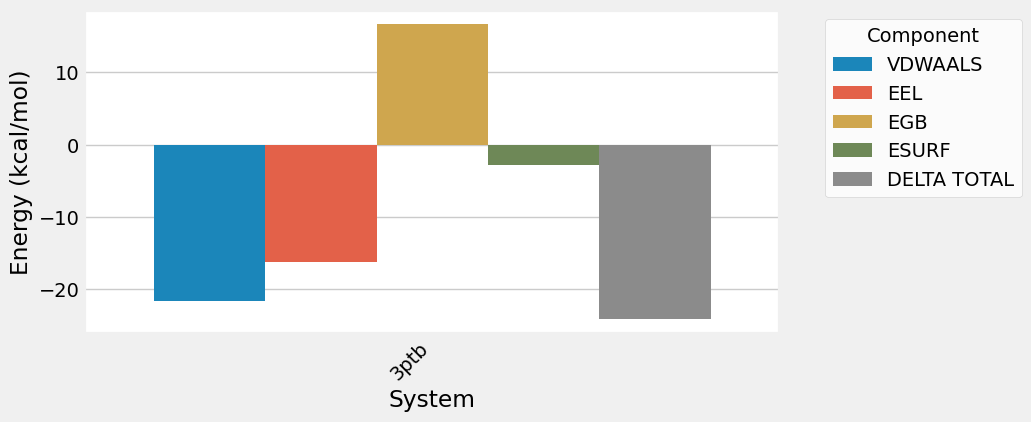

In [3]:
plt.figure(figsize=(8, 4))
order = df_all.groupby('system')['Average'].sum().sort_values().index
sns.barplot(data=df_all, x='system', y='Average', hue='Component', order=order)
plt.ylabel('Energy (kcal/mol)'); plt.xlabel('System')
plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.savefig(f'{sysname}/plots_mmgbsa/mmgbsa_percomponent_barplot.png', dpi=300, bbox_inches='tight')


### Check Total Energy for all compounds

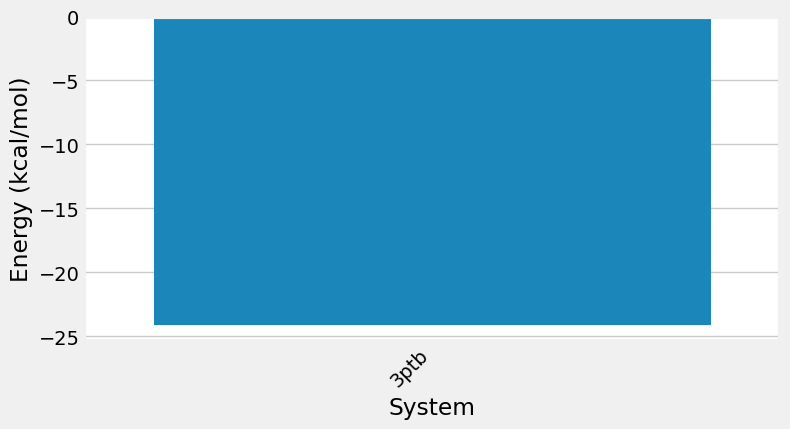

In [4]:
allsystems_total = df_all[df_all['Component'] == 'DELTA TOTAL'].copy()
plt.figure(figsize=(8, 4))
order = allsystems_total.groupby('system')['Average'].sum().sort_values().index
sns.barplot(data=allsystems_total, x='system', y='Average', order=order)
plt.ylabel('Energy (kcal/mol)'); plt.xlabel('System')
# plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.savefig(f'{sysname}/plots_mmgbsa/mmgbsa_totalEnergy_barplot.png', dpi=300, bbox_inches='tight')
